In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'MobileNetV2'
MODEL_NAME

'MobileNetV2'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for MobileNetV2 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class MobileNetV2(nn.Module):
    """
    MobileNetV2-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: MobileNetV2 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained MobileNetV2
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
        backbone = models.mobilenet_v2(weights=weights)

        # MobileNetV2 .features contains all the convolutional layers (Inverted Residuals)
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
        # MobileNetV2 output feature map has 1280 channels
        self.in_features = 1280 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1280, H, W) -> (Batch, 1280, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1280, 1, 1) -> (Batch, 1280)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [11]:
def build_mobilenetv2(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> MobileNetV2:
    """
    Factory function to instantiate the customized MobileNetV2 model for Transfer Learning.

    This function initializes a `MobileNetV2` which includes:
    1. A frozen MobileNetV2 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        MobileNetV2: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = MobileNetV2(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the MobileNetV2 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-4.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_mobilenetv2().to(device=device)

    # Model Summary
    print(f"\nFold: {fold_k} - Block 5")
    
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1
            ))
    
    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_5_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        # Disable BatchNorm
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_5_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_mobilenetv2().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 5)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of MobileNetV2 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of MobileNetV2 (torchvision) Feature Indices:
    - Block 5 (Deepest, 7x7 maps): Starts at index 14.
    - Block 4 (Intermediate, 14x14 maps): Starts at index 11.
    - Block 3 (Middle, 14x14 maps): Starts at index 7.
    - Block 2 (Shallow, 28x28 maps): Starts at index 4.
    - Block 1 (Full Network): Starts at index 0.

    Args:
        model (nn.Module): The MobileNetV2 model instance.
        block_num (int): The block number (1 to 5) from which to start training.
            - 5: Train only the final semantic features (Layers 14-18).
            - 1: Train the entire network.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.features
    block_indices = {
        5: 14,
        4: 11,
        3: 7,
        2: 4,
        1: 0,
    }

    start_index = block_indices[block_num]

    # 1. Configure Backbone (Feature Extractor)
    # Iterate through all layers in the 'features' sequential module
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            # Unfreeze: Allow gradient updates for layers in this block and above
            for param in child.parameters():
                param.requires_grad = True
        else:
            # Freeze: Prevent gradient updates for lower layers to preserve learned features
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head
    # The classification head (Linear layers) must always be trainable during fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the MobileNetV2 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features without destroying them.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The MobileNetV2 block number to unfreeze (e.g., 5, 4, 3...).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to MODEL_NAME.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_mobilenetv2().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    # Use the helper function to set requires_grad=True for the target block
    set_trainable_from_block(model=model, block_num=block)

    # Summary
    print(f"\nFold: {fold_k} - Block {block}")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)
                
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific MobileNetV2 block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    model = build_mobilenetv2().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 5
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 158MB/s]



Fold: 1 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (MB): 3419

Epoch 1/50 | loss: 0.4812 - accuracy: 0.4572 | val_loss: 0.3553 - val_accuracy: 0.6513
val_accuracy improved from 0.0000 to 0.6513, saving weights to /kaggle/working/MobileNetV2_block_5_fold_1.pth


Epoch 2/50 | loss: 0.3392 - accuracy: 0.6316 | val_loss: 0.2759 - val_accuracy: 0.7417
val_accuracy improved from 0.6513 to 0.7417, saving weights to /kaggle/working/MobileNetV2_block_5_fold_1.pth


...

Epoch 23/50 | loss: 0.1394 - accuracy: 0.8450 | val_loss: 0.1236 - val_accuracy: 0.8801
val_accuracy did not improve from 0.8985


Epoch 24/50 | loss: 0.1391 - accuracy: 0.8394 | val_loss: 0.1256 - val_accuracy: 0.8893
val_accuracy did not improve from 0.8985


Epoch 25/50 | loss: 0.1344 - accuracy: 0.8557 | val_loss: 0.1212 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8985


Epoch 26/50 | loss: 0.1344 - accuracy: 0.8454 | val_loss: 0.1205 - val_accuracy: 0.8856
val_accuracy did not improve from 0.8985


Epoch 27/50 | loss: 0.1274 - accuracy: 0.8466 | val_loss: 0.1236 - val_accuracy: 0.8893
val_accuracy did not improve from 0.8985
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.121361  0.898524
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.96      0.93       245
Meningioma Tumor       0.81      0.79      0.80       112
 Pituitary Tumor       0.94      0.89      0.91       185

        accuracy                           0.90       542
       macro avg       0.89      0.88      0.88       542
    weighted avg       0.90      0.90      0.90       542



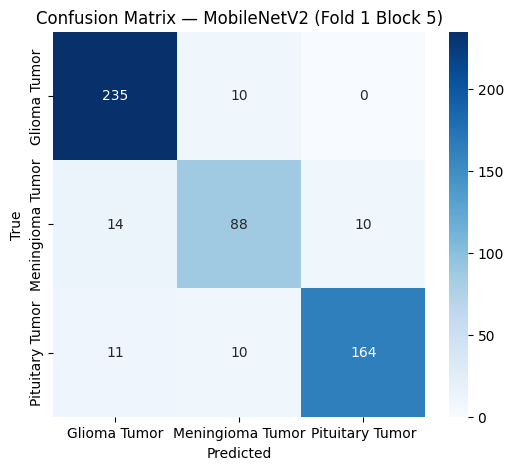

Fold: 1 block 4

Fold: 1 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1327 - accuracy: 0.8469 | val_loss: 0.0866 - val_accuracy: 0.9207
val_accuracy improved from 0.0000 to 0.9207, saving weights to /kaggle/working/MobileNetV2_block_4_fold_1.pth


Epoch 2/50 | loss: 0.1087 - accuracy: 0.8703 | val_loss: 0.0851 - val_accuracy: 0.9225
val_accuracy improved from 0.9207 to 0.9225, saving weights to /kaggle/working/MobileNetV2_block_4_fold_1.pth


Epoch 3/50 | loss: 0.0922 - accuracy: 0.8914 | val_loss: 0.0755 - val_accuracy: 0.9317
val_accuracy improved from 0.9225 to 0.9317, saving weights to /kaggle/working/MobileNetV2_block_4_fold_1.pth


Epoch 4/50 | loss: 0.0853 - accuracy: 0.9013 | val_loss: 0.0851 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9317


...

Epoch 10/50 | loss: 0.0649 - accuracy: 0.9179 | val_loss: 0.0627 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9446


Epoch 11/50 | loss: 0.0501 - accuracy: 0.9381 | val_loss: 0.0629 - val_accuracy: 0.9354
val_accuracy did not improve from 0.9446


Epoch 12/50 | loss: 0.0512 - accuracy: 0.9318 | val_loss: 0.0550 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9446


Epoch 13/50 | loss: 0.0497 - accuracy: 0.9322 | val_loss: 0.0534 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9446


Epoch 14/50 | loss: 0.0497 - accuracy: 0.9389 | val_loss: 0.0576 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9446
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.058112  0.944649
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.92      0.95       245
Meningioma Tumor       0.83      0.94      0.88       112
 Pituitary Tumor       0.97      0.98      0.98       185

        accuracy                           0.94       542
       macro avg       0.93      0.95      0.94       542
    weighted avg       0.95      0.94      0.95       542



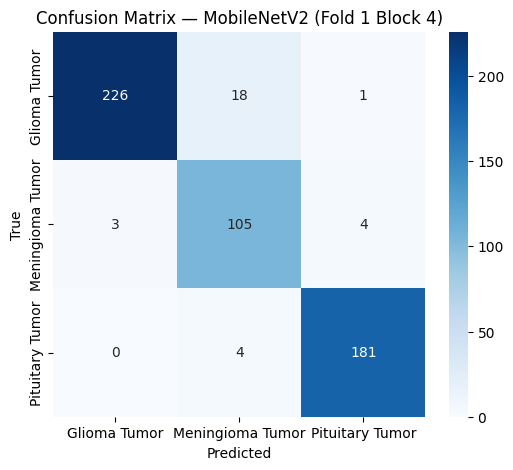

Fold: 1 block 3

Fold: 1 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0700 - accuracy: 0.9136 | val_loss: 0.0550 - val_accuracy: 0.9446
val_accuracy improved from 0.0000 to 0.9446, saving weights to /kaggle/working/MobileNetV2_block_3_fold_1.pth


Epoch 2/50 | loss: 0.0549 - accuracy: 0.9334 | val_loss: 0.0509 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9446


Epoch 3/50 | loss: 0.0557 - accuracy: 0.9259 | val_loss: 0.0528 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9446


Epoch 4/50 | loss: 0.0490 - accuracy: 0.9354 | val_loss: 0.0656 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9446


Epoch 5/50 | loss: 0.0524 - accuracy: 0.9358 | val_loss: 0.0765 - val_accuracy: 0.9041
val_accuracy did not improve from 0.9446


Epoch 6/50 | loss: 0.0449 - accuracy: 0.9409 | val_loss: 0.0547 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9446


Epoch 7/50 | loss: 0.0421 - accuracy: 0.9477 | val_loss: 0.0473 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9446
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.055001  0.944649
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.95      0.96       245
Meningioma Tumor       0.83      0.94      0.88       112
 Pituitary Tumor       0.99      0.94      0.97       185

        accuracy                           0.94       542
       macro avg       0.93      0.94      0.94       542
    weighted avg       0.95      0.94      0.95       542



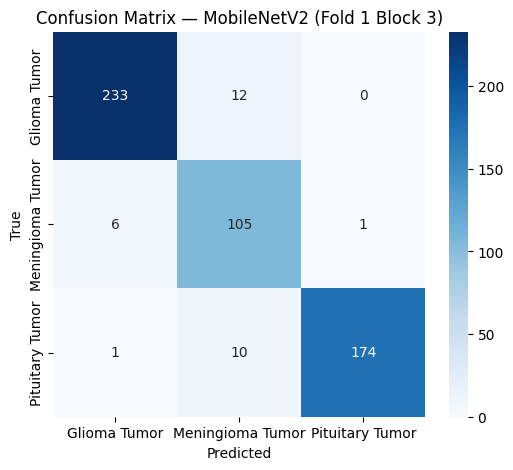

Fold: 1 block 2

Fold: 1 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,211,923
Non-trainable params: 15,792
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0543 - accuracy: 0.9334 | val_loss: 0.0535 - val_accuracy: 0.9391
val_accuracy improved from 0.0000 to 0.9391, saving weights to /kaggle/working/MobileNetV2_block_2_fold_1.pth


Epoch 2/50 | loss: 0.0538 - accuracy: 0.9290 | val_loss: 0.0848 - val_accuracy: 0.8985
val_accuracy did not improve from 0.9391


Epoch 3/50 | loss: 0.0533 - accuracy: 0.9350 | val_loss: 0.0541 - val_accuracy: 0.9428
val_accuracy improved from 0.9391 to 0.9428, saving weights to /kaggle/working/MobileNetV2_block_2_fold_1.pth


Epoch 4/50 | loss: 0.0459 - accuracy: 0.9413 | val_loss: 0.0406 - val_accuracy: 0.9576
val_accuracy improved from 0.9428 to 0.9576, saving weights to /kaggle/working/MobileNetV2_block_2_fold_1.pth


...

Epoch 14/50 | loss: 0.0259 - accuracy: 0.9631 | val_loss: 0.0343 - val_accuracy: 0.9649
val_accuracy did not improve from 0.9686


Epoch 15/50 | loss: 0.0289 - accuracy: 0.9647 | val_loss: 0.0348 - val_accuracy: 0.9649
val_accuracy did not improve from 0.9686


Epoch 16/50 | loss: 0.0263 - accuracy: 0.9627 | val_loss: 0.0403 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9686


Epoch 17/50 | loss: 0.0263 - accuracy: 0.9671 | val_loss: 0.0382 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9686


Epoch 18/50 | loss: 0.0224 - accuracy: 0.9711 | val_loss: 0.0370 - val_accuracy: 0.9668
val_accuracy did not improve from 0.9686
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.036831  0.968635
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.95      0.97       245
Meningioma Tumor       0.89      0.97      0.93       112
 Pituitary Tumor       0.99      0.99      0.99       185

        accuracy                           0.97       542
       macro avg       0.96      0.97      0.96       542
    weighted avg       0.97      0.97      0.97       542



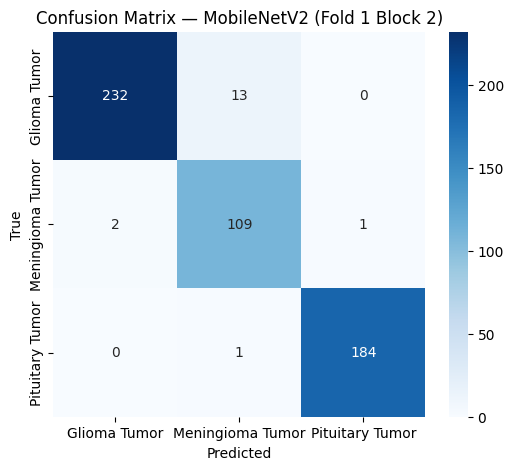

Fold: 1 block 1

Fold: 1 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0391 - accuracy: 0.9492 | val_loss: 0.0585 - val_accuracy: 0.9336
val_accuracy improved from 0.0000 to 0.9336, saving weights to /kaggle/working/MobileNetV2_block_1_fold_1.pth


Epoch 2/50 | loss: 0.0357 - accuracy: 0.9600 | val_loss: 0.0369 - val_accuracy: 0.9557
val_accuracy improved from 0.9336 to 0.9557, saving weights to /kaggle/working/MobileNetV2_block_1_fold_1.pth


Epoch 3/50 | loss: 0.0318 - accuracy: 0.9631 | val_loss: 0.0357 - val_accuracy: 0.9613
val_accuracy improved from 0.9557 to 0.9613, saving weights to /kaggle/working/MobileNetV2_block_1_fold_1.pth


Epoch 4/50 | loss: 0.0258 - accuracy: 0.9671 | val_loss: 0.0661 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9613


...

Epoch 7/50 | loss: 0.0205 - accuracy: 0.9742 | val_loss: 0.0342 - val_accuracy: 0.9613
val_accuracy did not improve from 0.9686


Epoch 8/50 | loss: 0.0225 - accuracy: 0.9711 | val_loss: 0.0629 - val_accuracy: 0.9354
val_accuracy did not improve from 0.9686


Epoch 9/50 | loss: 0.0189 - accuracy: 0.9774 | val_loss: 0.0307 - val_accuracy: 0.9668
val_accuracy did not improve from 0.9686


Epoch 10/50 | loss: 0.0204 - accuracy: 0.9754 | val_loss: 0.0343 - val_accuracy: 0.9613
val_accuracy did not improve from 0.9686


Epoch 11/50 | loss: 0.0162 - accuracy: 0.9814 | val_loss: 0.0344 - val_accuracy: 0.9649
val_accuracy did not improve from 0.9686
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.033182  0.968635
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       245
Meningioma Tumor       0.93      0.94      0.93       112
 Pituitary Tumor       1.00      0.97      0.99       185

        accuracy                           0.97       542
       macro avg       0.96      0.96      0.96       542
    weighted avg       0.97      0.97      0.97       542



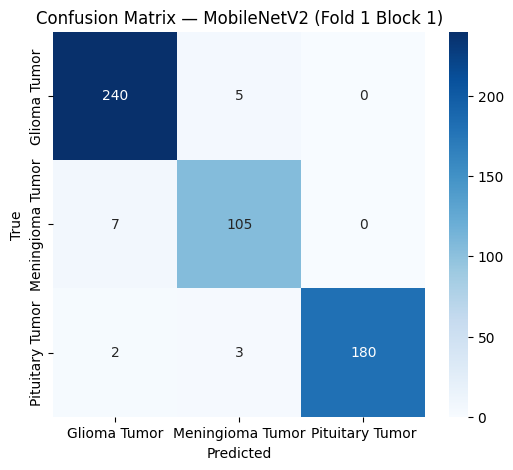

Fold: 2 block 5

Fold: 2 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4282 - accuracy: 0.5082 | val_loss: 0.3238 - val_accuracy: 0.6510
val_accuracy improved from 0.0000 to 0.6510, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


Epoch 2/50 | loss: 0.3141 - accuracy: 0.6751 | val_loss: 0.2581 - val_accuracy: 0.7585
val_accuracy improved from 0.6510 to 0.7585, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


Epoch 3/50 | loss: 0.2634 - accuracy: 0.7371 | val_loss: 0.2314 - val_accuracy: 0.7614
val_accuracy improved from 0.7585 to 0.7614, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


Epoch 4/50 | loss: 0.2329 - accuracy: 0.7648 | val_loss: 0.2117 - val_accuracy: 0.7791
val_accuracy improved from 0.7614 to 0.7791, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


...

Epoch 13/50 | loss: 0.1587 - accuracy: 0.8344 | val_loss: 0.1665 - val_accuracy: 0.8071
val_accuracy did not improve from 0.8203


Epoch 14/50 | loss: 0.1541 - accuracy: 0.8298 | val_loss: 0.1708 - val_accuracy: 0.8027
val_accuracy did not improve from 0.8203


Epoch 15/50 | loss: 0.1549 - accuracy: 0.8356 | val_loss: 0.1623 - val_accuracy: 0.7997
val_accuracy did not improve from 0.8203


Epoch 16/50 | loss: 0.1452 - accuracy: 0.8465 | val_loss: 0.1631 - val_accuracy: 0.8085
val_accuracy did not improve from 0.8203


Epoch 17/50 | loss: 0.1452 - accuracy: 0.8436 | val_loss: 0.1588 - val_accuracy: 0.8100
val_accuracy did not improve from 0.8203
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.159695  0.820324
                  precision    recall  f1-score   support

    Glioma Tumor       0.83      0.89      0.86       338
Meningioma Tumor       0.74      0.57      0.64       167
 Pituitary Tumor       0.86      0.92      0.89       174

        accuracy                           0.82       679
       macro avg       0.81      0.79      0.80       679
    weighted avg       0.81      0.82      0.81       679



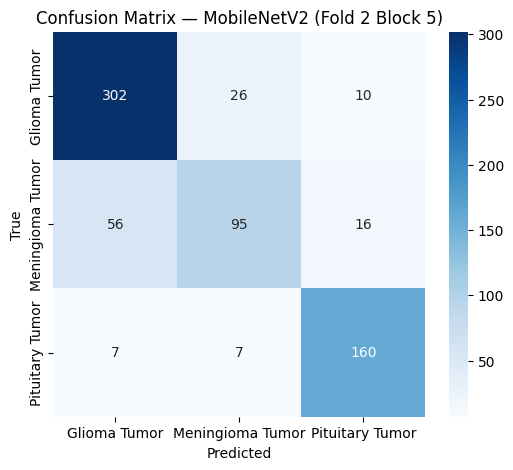

Fold: 2 block 4

Fold: 2 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1512 - accuracy: 0.8361 | val_loss: 0.1325 - val_accuracy: 0.8424
val_accuracy improved from 0.0000 to 0.8424, saving weights to /kaggle/working/MobileNetV2_block_4_fold_2.pth


Epoch 2/50 | loss: 0.1173 - accuracy: 0.8637 | val_loss: 0.1464 - val_accuracy: 0.8262
val_accuracy did not improve from 0.8424


Epoch 3/50 | loss: 0.1048 - accuracy: 0.8721 | val_loss: 0.1222 - val_accuracy: 0.8542
val_accuracy improved from 0.8424 to 0.8542, saving weights to /kaggle/working/MobileNetV2_block_4_fold_2.pth


Epoch 4/50 | loss: 0.0906 - accuracy: 0.8935 | val_loss: 0.1115 - val_accuracy: 0.8601
val_accuracy improved from 0.8542 to 0.8601, saving weights to /kaggle/working/MobileNetV2_block_4_fold_2.pth


...

Epoch 18/50 | loss: 0.0531 - accuracy: 0.9342 | val_loss: 0.1000 - val_accuracy: 0.8778
val_accuracy did not improve from 0.8866


Epoch 19/50 | loss: 0.0516 - accuracy: 0.9384 | val_loss: 0.0971 - val_accuracy: 0.8822
val_accuracy did not improve from 0.8866


Epoch 20/50 | loss: 0.0464 - accuracy: 0.9371 | val_loss: 0.0957 - val_accuracy: 0.8837
val_accuracy did not improve from 0.8866


Epoch 21/50 | loss: 0.0470 - accuracy: 0.9434 | val_loss: 0.1041 - val_accuracy: 0.8837
val_accuracy did not improve from 0.8866


Epoch 22/50 | loss: 0.0465 - accuracy: 0.9455 | val_loss: 0.1000 - val_accuracy: 0.8792
val_accuracy did not improve from 0.8866
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.094123  0.886598
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.94      0.92       338
Meningioma Tumor       0.80      0.77      0.78       167
 Pituitary Tumor       0.95      0.90      0.92       174

        accuracy                           0.89       679
       macro avg       0.88      0.87      0.87       679
    weighted avg       0.89      0.89      0.89       679



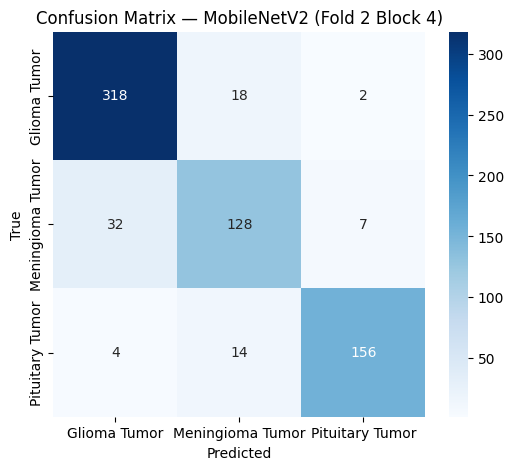

Fold: 2 block 3

Fold: 2 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0574 - accuracy: 0.9258 | val_loss: 0.0922 - val_accuracy: 0.8940
val_accuracy improved from 0.0000 to 0.8940, saving weights to /kaggle/working/MobileNetV2_block_3_fold_2.pth


Epoch 2/50 | loss: 0.0527 - accuracy: 0.9317 | val_loss: 0.0878 - val_accuracy: 0.9013
val_accuracy improved from 0.8940 to 0.9013, saving weights to /kaggle/working/MobileNetV2_block_3_fold_2.pth


Epoch 3/50 | loss: 0.0511 - accuracy: 0.9342 | val_loss: 0.1108 - val_accuracy: 0.8763
val_accuracy did not improve from 0.9013


Epoch 4/50 | loss: 0.0468 - accuracy: 0.9447 | val_loss: 0.0853 - val_accuracy: 0.8984
val_accuracy did not improve from 0.9013


Epoch 5/50 | loss: 0.0467 - accuracy: 0.9388 | val_loss: 0.0963 - val_accuracy: 0.8940
val_accuracy did not improve from 0.9013


Epoch 6/50 | loss: 0.0417 - accuracy: 0.9472 | val_loss: 0.1265 - val_accuracy: 0.8557
val_accuracy did not improve from 0.9013


Epoch 7/50 | loss: 0.0358 - accuracy: 0.9568 | val_loss: 0.1167 - val_accuracy: 0.8851
val_accuracy did not improve from 0.9013


Epoch 8/50 | loss: 0.0339 - accuracy: 0.9522 | val_loss: 0.0966 - val_accuracy: 0.9013
val_accuracy did not improve from 0.9013
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.087825  0.901325
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       338
Meningioma Tumor       0.80      0.83      0.81       167
 Pituitary Tumor       0.94      0.91      0.92       174

        accuracy                           0.90       679
       macro avg       0.89      0.89      0.89       679
    weighted avg       0.90      0.90      0.90       679



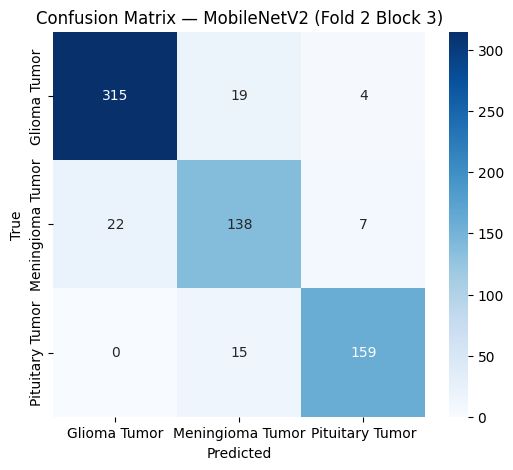

Fold: 2 block 2

Fold: 2 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,211,923
Non-trainable params: 15,792
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0485 - accuracy: 0.9409 | val_loss: 0.1024 - val_accuracy: 0.8895
val_accuracy improved from 0.0000 to 0.8895, saving weights to /kaggle/working/MobileNetV2_block_2_fold_2.pth


Epoch 2/50 | loss: 0.0499 - accuracy: 0.9346 | val_loss: 0.1088 - val_accuracy: 0.8792
val_accuracy did not improve from 0.8895


Epoch 3/50 | loss: 0.0399 - accuracy: 0.9451 | val_loss: 0.0941 - val_accuracy: 0.9013
val_accuracy improved from 0.8895 to 0.9013, saving weights to /kaggle/working/MobileNetV2_block_2_fold_2.pth


Epoch 4/50 | loss: 0.0372 - accuracy: 0.9497 | val_loss: 0.1212 - val_accuracy: 0.8851
val_accuracy did not improve from 0.9013


Epoch 5/50 | loss: 0.0346 - accuracy: 0.9589 | val_loss: 0.1379 - val_accuracy: 0.8601
val_accuracy did not improve from 0.9013


Epoch 6/50 | loss: 0.0329 - accuracy: 0.9568 | val_loss: 0.1185 - val_accuracy: 0.8866
val_accuracy did not improve from 0.9013


Epoch 7/50 | loss: 0.0308 - accuracy: 0.9597 | val_loss: 0.1057 - val_accuracy: 0.8895
val_accuracy did not improve from 0.9013


Epoch 8/50 | loss: 0.0256 - accuracy: 0.9702 | val_loss: 0.0990 - val_accuracy: 0.8940
val_accuracy did not improve from 0.9013


Epoch 9/50 | loss: 0.0249 - accuracy: 0.9711 | val_loss: 0.0932 - val_accuracy: 0.9013
val_accuracy did not improve from 0.9013
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.094106  0.901325
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.92      0.93       338
Meningioma Tumor       0.80      0.84      0.82       167
 Pituitary Tumor       0.92      0.93      0.92       174

        accuracy                           0.90       679
       macro avg       0.89      0.90      0.89       679
    weighted avg       0.90      0.90      0.90       679



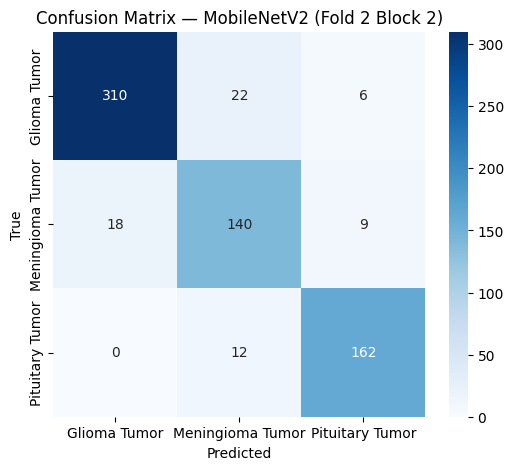

Fold: 2 block 1

Fold: 2 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0432 - accuracy: 0.9476 | val_loss: 0.0940 - val_accuracy: 0.8895
val_accuracy improved from 0.0000 to 0.8895, saving weights to /kaggle/working/MobileNetV2_block_1_fold_2.pth


Epoch 2/50 | loss: 0.0454 - accuracy: 0.9434 | val_loss: 0.0810 - val_accuracy: 0.9057
val_accuracy improved from 0.8895 to 0.9057, saving weights to /kaggle/working/MobileNetV2_block_1_fold_2.pth


Epoch 3/50 | loss: 0.0326 - accuracy: 0.9589 | val_loss: 0.0915 - val_accuracy: 0.8984
val_accuracy did not improve from 0.9057


Epoch 4/50 | loss: 0.0356 - accuracy: 0.9514 | val_loss: 0.0850 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9057


...

Epoch 13/50 | loss: 0.0187 - accuracy: 0.9769 | val_loss: 0.0957 - val_accuracy: 0.9043
val_accuracy did not improve from 0.9161


Epoch 14/50 | loss: 0.0162 - accuracy: 0.9799 | val_loss: 0.0851 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9161


Epoch 15/50 | loss: 0.0133 - accuracy: 0.9836 | val_loss: 0.0911 - val_accuracy: 0.9087
val_accuracy did not improve from 0.9161


Epoch 16/50 | loss: 0.0153 - accuracy: 0.9820 | val_loss: 0.0936 - val_accuracy: 0.9087
val_accuracy did not improve from 0.9161


Epoch 17/50 | loss: 0.0150 - accuracy: 0.9803 | val_loss: 0.0916 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9161
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.086596  0.916053
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.95      0.94       338
Meningioma Tumor       0.83      0.87      0.85       167
 Pituitary Tumor       0.97      0.90      0.93       174

        accuracy                           0.92       679
       macro avg       0.91      0.90      0.91       679
    weighted avg       0.92      0.92      0.92       679



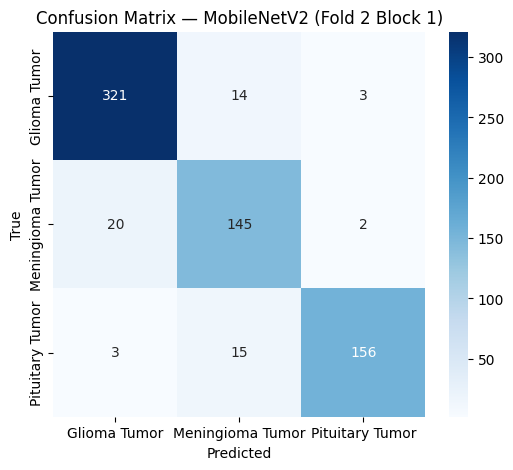

Fold: 3 block 5

Fold: 3 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4546 - accuracy: 0.4984 | val_loss: 0.3628 - val_accuracy: 0.6469
val_accuracy improved from 0.0000 to 0.6469, saving weights to /kaggle/working/MobileNetV2_block_5_fold_3.pth


Epoch 2/50 | loss: 0.3301 - accuracy: 0.6705 | val_loss: 0.2948 - val_accuracy: 0.7413
val_accuracy improved from 0.6469 to 0.7413, saving weights to /kaggle/working/MobileNetV2_block_5_fold_3.pth


Epoch 3/50 | loss: 0.2685 - accuracy: 0.7368 | val_loss: 0.2676 - val_accuracy: 0.7395
val_accuracy did not improve from 0.7413


Epoch 4/50 | loss: 0.2376 - accuracy: 0.7600 | val_loss: 0.2386 - val_accuracy: 0.7832
val_accuracy improved from 0.7413 to 0.7832, saving weights to /kaggle/working/MobileNetV2_block_5_fold_3.pth


...

Epoch 10/50 | loss: 0.1681 - accuracy: 0.8202 | val_loss: 0.1919 - val_accuracy: 0.7902
val_accuracy did not improve from 0.8269


Epoch 11/50 | loss: 0.1582 - accuracy: 0.8319 | val_loss: 0.1857 - val_accuracy: 0.7990
val_accuracy did not improve from 0.8269


Epoch 12/50 | loss: 0.1555 - accuracy: 0.8359 | val_loss: 0.1799 - val_accuracy: 0.8129
val_accuracy did not improve from 0.8269


Epoch 13/50 | loss: 0.1538 - accuracy: 0.8335 | val_loss: 0.1747 - val_accuracy: 0.8217
val_accuracy did not improve from 0.8269


Epoch 14/50 | loss: 0.1481 - accuracy: 0.8455 | val_loss: 0.1714 - val_accuracy: 0.8252
val_accuracy did not improve from 0.8269
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.189989  0.826923
                  precision    recall  f1-score   support

    Glioma Tumor       0.81      0.84      0.82       231
Meningioma Tumor       0.71      0.67      0.69       139
 Pituitary Tumor       0.92      0.93      0.92       202

        accuracy                           0.83       572
       macro avg       0.81      0.81      0.81       572
    weighted avg       0.83      0.83      0.83       572



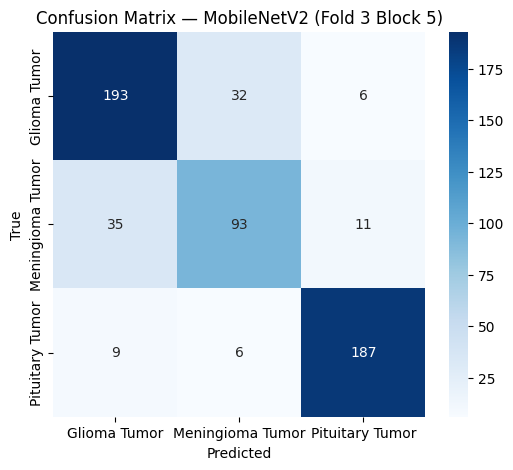

Fold: 3 block 4

Fold: 3 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1573 - accuracy: 0.8327 | val_loss: 0.1465 - val_accuracy: 0.8462
val_accuracy improved from 0.0000 to 0.8462, saving weights to /kaggle/working/MobileNetV2_block_4_fold_3.pth


Epoch 2/50 | loss: 0.1228 - accuracy: 0.8591 | val_loss: 0.1526 - val_accuracy: 0.8094
val_accuracy did not improve from 0.8462


Epoch 3/50 | loss: 0.0990 - accuracy: 0.8884 | val_loss: 0.1162 - val_accuracy: 0.8759
val_accuracy improved from 0.8462 to 0.8759, saving weights to /kaggle/working/MobileNetV2_block_4_fold_3.pth


Epoch 4/50 | loss: 0.0917 - accuracy: 0.8933 | val_loss: 0.1203 - val_accuracy: 0.8566
val_accuracy did not improve from 0.8759


...

Epoch 20/50 | loss: 0.0352 - accuracy: 0.9579 | val_loss: 0.1184 - val_accuracy: 0.8829
val_accuracy did not improve from 0.8951


Epoch 21/50 | loss: 0.0342 - accuracy: 0.9587 | val_loss: 0.1090 - val_accuracy: 0.8899
val_accuracy did not improve from 0.8951


Epoch 22/50 | loss: 0.0368 - accuracy: 0.9583 | val_loss: 0.1104 - val_accuracy: 0.8899
val_accuracy did not improve from 0.8951


Epoch 23/50 | loss: 0.0337 - accuracy: 0.9543 | val_loss: 0.1084 - val_accuracy: 0.8899
val_accuracy did not improve from 0.8951


Epoch 24/50 | loss: 0.0312 - accuracy: 0.9635 | val_loss: 0.1126 - val_accuracy: 0.8881
val_accuracy did not improve from 0.8951
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.112233  0.895105
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.86      0.89       231
Meningioma Tumor       0.78      0.83      0.80       139
 Pituitary Tumor       0.95      0.99      0.97       202

        accuracy                           0.90       572
       macro avg       0.88      0.89      0.89       572
    weighted avg       0.90      0.90      0.90       572



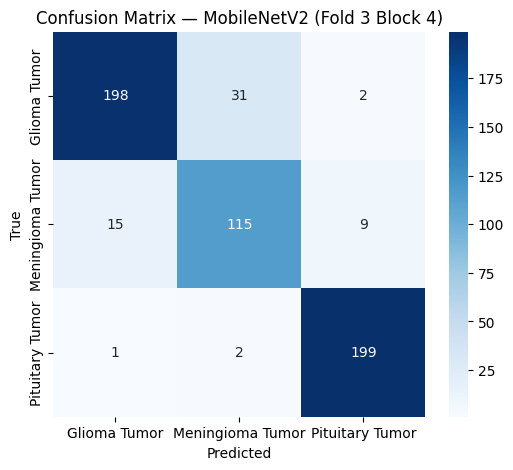

Fold: 3 block 3

Fold: 3 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0451 - accuracy: 0.9470 | val_loss: 0.1051 - val_accuracy: 0.8881
val_accuracy improved from 0.0000 to 0.8881, saving weights to /kaggle/working/MobileNetV2_block_3_fold_3.pth


Epoch 2/50 | loss: 0.0367 - accuracy: 0.9555 | val_loss: 0.1294 - val_accuracy: 0.8864
val_accuracy did not improve from 0.8881


Epoch 3/50 | loss: 0.0403 - accuracy: 0.9502 | val_loss: 0.1082 - val_accuracy: 0.8759
val_accuracy did not improve from 0.8881


Epoch 4/50 | loss: 0.0399 - accuracy: 0.9530 | val_loss: 0.1044 - val_accuracy: 0.8969
val_accuracy improved from 0.8881 to 0.8969, saving weights to /kaggle/working/MobileNetV2_block_3_fold_3.pth


...

Epoch 8/50 | loss: 0.0259 - accuracy: 0.9667 | val_loss: 0.0929 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9073


Epoch 9/50 | loss: 0.0217 - accuracy: 0.9743 | val_loss: 0.1357 - val_accuracy: 0.8916
val_accuracy did not improve from 0.9073


Epoch 10/50 | loss: 0.0273 - accuracy: 0.9671 | val_loss: 0.0960 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9073


Epoch 11/50 | loss: 0.0198 - accuracy: 0.9739 | val_loss: 0.1019 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9073


Epoch 12/50 | loss: 0.0191 - accuracy: 0.9763 | val_loss: 0.1081 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9073
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.092632  0.907343
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.87      0.90       231
Meningioma Tumor       0.80      0.85      0.82       139
 Pituitary Tumor       0.96      0.99      0.98       202

        accuracy                           0.91       572
       macro avg       0.90      0.90      0.90       572
    weighted avg       0.91      0.91      0.91       572



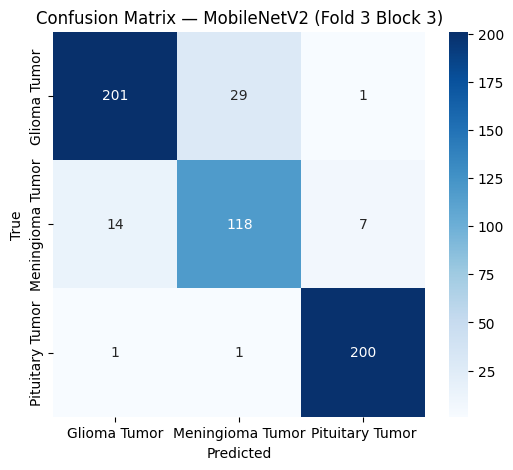

Fold: 3 block 2

Fold: 3 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,211,923
Non-trainable params: 15,792
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0278 - accuracy: 0.9671 | val_loss: 0.1128 - val_accuracy: 0.8951
val_accuracy improved from 0.0000 to 0.8951, saving weights to /kaggle/working/MobileNetV2_block_2_fold_3.pth


Epoch 2/50 | loss: 0.0332 - accuracy: 0.9603 | val_loss: 0.0966 - val_accuracy: 0.8969
val_accuracy improved from 0.8951 to 0.8969, saving weights to /kaggle/working/MobileNetV2_block_2_fold_3.pth


Epoch 3/50 | loss: 0.0318 - accuracy: 0.9643 | val_loss: 0.0883 - val_accuracy: 0.9143
val_accuracy improved from 0.8969 to 0.9143, saving weights to /kaggle/working/MobileNetV2_block_2_fold_3.pth


Epoch 4/50 | loss: 0.0251 - accuracy: 0.9703 | val_loss: 0.1338 - val_accuracy: 0.8846
val_accuracy did not improve from 0.9143


...

Epoch 8/50 | loss: 0.0202 - accuracy: 0.9775 | val_loss: 0.1110 - val_accuracy: 0.9091
val_accuracy did not improve from 0.9178


Epoch 9/50 | loss: 0.0208 - accuracy: 0.9759 | val_loss: 0.1022 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9178


Epoch 10/50 | loss: 0.0173 - accuracy: 0.9803 | val_loss: 0.1239 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9178


Epoch 11/50 | loss: 0.0106 - accuracy: 0.9864 | val_loss: 0.1038 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9178


Epoch 12/50 | loss: 0.0128 - accuracy: 0.9860 | val_loss: 0.1196 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9178
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.088169  0.917832
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.89      0.92       231
Meningioma Tumor       0.82      0.87      0.84       139
 Pituitary Tumor       0.97      0.98      0.97       202

        accuracy                           0.92       572
       macro avg       0.91      0.91      0.91       572
    weighted avg       0.92      0.92      0.92       572



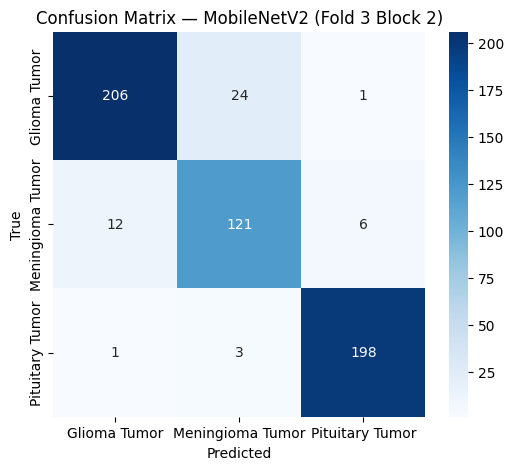

Fold: 3 block 1

Fold: 3 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0228 - accuracy: 0.9699 | val_loss: 0.1547 - val_accuracy: 0.8899
val_accuracy improved from 0.0000 to 0.8899, saving weights to /kaggle/working/MobileNetV2_block_1_fold_3.pth


Epoch 2/50 | loss: 0.0207 - accuracy: 0.9743 | val_loss: 0.1541 - val_accuracy: 0.8969
val_accuracy improved from 0.8899 to 0.8969, saving weights to /kaggle/working/MobileNetV2_block_1_fold_3.pth


Epoch 3/50 | loss: 0.0208 - accuracy: 0.9739 | val_loss: 0.1339 - val_accuracy: 0.8899
val_accuracy did not improve from 0.8969


Epoch 4/50 | loss: 0.0140 - accuracy: 0.9799 | val_loss: 0.0985 - val_accuracy: 0.9143
val_accuracy improved from 0.8969 to 0.9143, saving weights to /kaggle/working/MobileNetV2_block_1_fold_3.pth


...

Epoch 9/50 | loss: 0.0100 - accuracy: 0.9876 | val_loss: 0.1014 - val_accuracy: 0.9161
val_accuracy did not improve from 0.9196


Epoch 10/50 | loss: 0.0094 - accuracy: 0.9892 | val_loss: 0.1260 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9196


Epoch 11/50 | loss: 0.0098 - accuracy: 0.9888 | val_loss: 0.1150 - val_accuracy: 0.9196
val_accuracy did not improve from 0.9196


Epoch 12/50 | loss: 0.0091 - accuracy: 0.9896 | val_loss: 0.1323 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9196


Epoch 13/50 | loss: 0.0081 - accuracy: 0.9916 | val_loss: 0.1064 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9196
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.109744   0.91958
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.88      0.91       231
Meningioma Tumor       0.81      0.88      0.85       139
 Pituitary Tumor       0.97      0.99      0.98       202

        accuracy                           0.92       572
       macro avg       0.91      0.92      0.91       572
    weighted avg       0.92      0.92      0.92       572



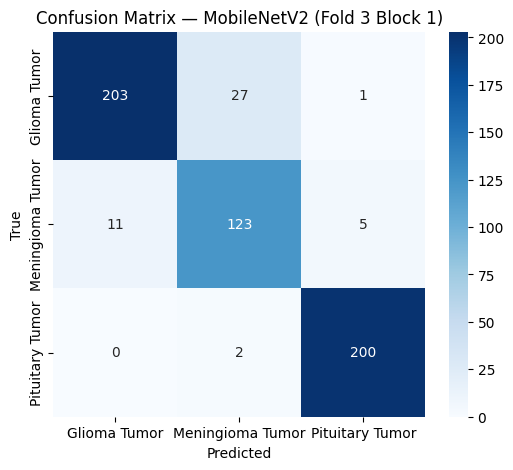

Fold: 4 block 5

Fold: 4 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4691 - accuracy: 0.4544 | val_loss: 0.3444 - val_accuracy: 0.7166
val_accuracy improved from 0.0000 to 0.7166, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


Epoch 2/50 | loss: 0.3385 - accuracy: 0.6470 | val_loss: 0.2570 - val_accuracy: 0.7866
val_accuracy improved from 0.7166 to 0.7866, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


Epoch 3/50 | loss: 0.2800 - accuracy: 0.7233 | val_loss: 0.2185 - val_accuracy: 0.8121
val_accuracy improved from 0.7866 to 0.8121, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


Epoch 4/50 | loss: 0.2469 - accuracy: 0.7496 | val_loss: 0.1914 - val_accuracy: 0.8471
val_accuracy improved from 0.8121 to 0.8471, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


...

Epoch 24/50 | loss: 0.1445 - accuracy: 0.8342 | val_loss: 0.1045 - val_accuracy: 0.9061
val_accuracy did not improve from 0.9076


Epoch 25/50 | loss: 0.1401 - accuracy: 0.8432 | val_loss: 0.1043 - val_accuracy: 0.9061
val_accuracy did not improve from 0.9076


Epoch 26/50 | loss: 0.1488 - accuracy: 0.8333 | val_loss: 0.1031 - val_accuracy: 0.9029
val_accuracy did not improve from 0.9076


Epoch 27/50 | loss: 0.1380 - accuracy: 0.8489 | val_loss: 0.1023 - val_accuracy: 0.9076
val_accuracy did not improve from 0.9076


Epoch 28/50 | loss: 0.1346 - accuracy: 0.8428 | val_loss: 0.1011 - val_accuracy: 0.8997
val_accuracy did not improve from 0.9076
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.105858  0.907643
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.94      0.95       325
Meningioma Tumor       0.81      0.74      0.78       124
 Pituitary Tumor       0.88      0.97      0.92       179

        accuracy                           0.91       628
       macro avg       0.88      0.88      0.88       628
    weighted avg       0.91      0.91      0.91       628



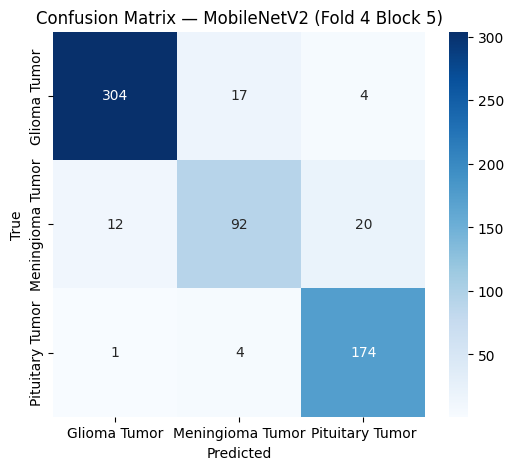

Fold: 4 block 4

Fold: 4 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1409 - accuracy: 0.8456 | val_loss: 0.1058 - val_accuracy: 0.8838
val_accuracy improved from 0.0000 to 0.8838, saving weights to /kaggle/working/MobileNetV2_block_4_fold_4.pth


Epoch 2/50 | loss: 0.1130 - accuracy: 0.8764 | val_loss: 0.0771 - val_accuracy: 0.9252
val_accuracy improved from 0.8838 to 0.9252, saving weights to /kaggle/working/MobileNetV2_block_4_fold_4.pth


Epoch 3/50 | loss: 0.0927 - accuracy: 0.8883 | val_loss: 0.0728 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9252


Epoch 4/50 | loss: 0.0932 - accuracy: 0.8855 | val_loss: 0.0723 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9252


...

Epoch 16/50 | loss: 0.0492 - accuracy: 0.9417 | val_loss: 0.0510 - val_accuracy: 0.9347
val_accuracy did not improve from 0.9459


Epoch 17/50 | loss: 0.0409 - accuracy: 0.9450 | val_loss: 0.0534 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9459


Epoch 18/50 | loss: 0.0360 - accuracy: 0.9503 | val_loss: 0.0666 - val_accuracy: 0.9395
val_accuracy did not improve from 0.9459


Epoch 19/50 | loss: 0.0398 - accuracy: 0.9507 | val_loss: 0.0538 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9459


Epoch 20/50 | loss: 0.0366 - accuracy: 0.9495 | val_loss: 0.0584 - val_accuracy: 0.9347
val_accuracy did not improve from 0.9459
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.055031   0.94586
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       325
Meningioma Tumor       0.89      0.85      0.87       124
 Pituitary Tumor       0.95      0.94      0.95       179

        accuracy                           0.95       628
       macro avg       0.94      0.93      0.93       628
    weighted avg       0.95      0.95      0.95       628



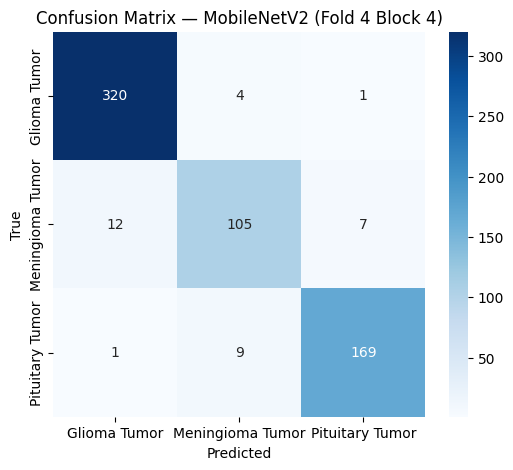

Fold: 4 block 3

Fold: 4 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0519 - accuracy: 0.9343 | val_loss: 0.0540 - val_accuracy: 0.9427
val_accuracy improved from 0.0000 to 0.9427, saving weights to /kaggle/working/MobileNetV2_block_3_fold_4.pth


Epoch 2/50 | loss: 0.0433 - accuracy: 0.9462 | val_loss: 0.0549 - val_accuracy: 0.9395
val_accuracy did not improve from 0.9427


Epoch 3/50 | loss: 0.0453 - accuracy: 0.9409 | val_loss: 0.0649 - val_accuracy: 0.9347
val_accuracy did not improve from 0.9427


Epoch 4/50 | loss: 0.0416 - accuracy: 0.9454 | val_loss: 0.0595 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9427


Epoch 5/50 | loss: 0.0387 - accuracy: 0.9429 | val_loss: 0.0782 - val_accuracy: 0.9156
val_accuracy did not improve from 0.9427


Epoch 6/50 | loss: 0.0355 - accuracy: 0.9602 | val_loss: 0.0503 - val_accuracy: 0.9411
val_accuracy did not improve from 0.9427


Epoch 7/50 | loss: 0.0306 - accuracy: 0.9589 | val_loss: 0.0513 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9427
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.054033  0.942675
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.96      0.97       325
Meningioma Tumor       0.86      0.89      0.87       124
 Pituitary Tumor       0.94      0.96      0.95       179

        accuracy                           0.94       628
       macro avg       0.93      0.93      0.93       628
    weighted avg       0.94      0.94      0.94       628



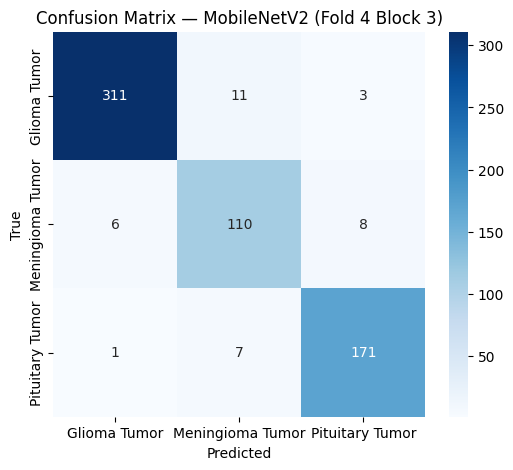

Fold: 4 block 2

Fold: 4 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,211,923
Non-trainable params: 15,792
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0486 - accuracy: 0.9388 | val_loss: 0.0549 - val_accuracy: 0.9427
val_accuracy improved from 0.0000 to 0.9427, saving weights to /kaggle/working/MobileNetV2_block_2_fold_4.pth


Epoch 2/50 | loss: 0.0418 - accuracy: 0.9454 | val_loss: 0.0641 - val_accuracy: 0.9268
val_accuracy did not improve from 0.9427


Epoch 3/50 | loss: 0.0387 - accuracy: 0.9511 | val_loss: 0.0629 - val_accuracy: 0.9204
val_accuracy did not improve from 0.9427


Epoch 4/50 | loss: 0.0379 - accuracy: 0.9540 | val_loss: 0.0539 - val_accuracy: 0.9315
val_accuracy did not improve from 0.9427


Epoch 5/50 | loss: 0.0356 - accuracy: 0.9569 | val_loss: 0.0484 - val_accuracy: 0.9363
val_accuracy did not improve from 0.9427


Epoch 6/50 | loss: 0.0350 - accuracy: 0.9528 | val_loss: 0.0542 - val_accuracy: 0.9411
val_accuracy did not improve from 0.9427


Epoch 7/50 | loss: 0.0330 - accuracy: 0.9606 | val_loss: 0.0490 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9427
early stopping, restoring model weights from the end of the best epoch
         Model     Loss  Accuracy
0  MobileNetV2  0.05494  0.942675
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.96      0.97       325
Meningioma Tumor       0.84      0.90      0.87       124
 Pituitary Tumor       0.97      0.94      0.95       179

        accuracy                           0.94       628
       macro avg       0.93      0.93      0.93       628
    weighted avg       0.94      0.94      0.94       628



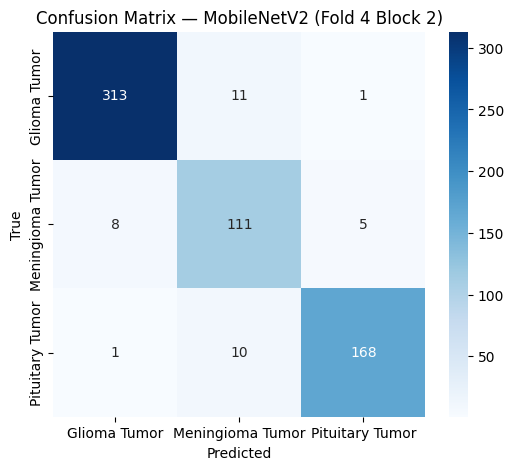

Fold: 4 block 1

Fold: 4 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0427 - accuracy: 0.9421 | val_loss: 0.0508 - val_accuracy: 0.9459
val_accuracy improved from 0.0000 to 0.9459, saving weights to /kaggle/working/MobileNetV2_block_1_fold_4.pth


Epoch 2/50 | loss: 0.0399 - accuracy: 0.9528 | val_loss: 0.0639 - val_accuracy: 0.9363
val_accuracy did not improve from 0.9459


Epoch 3/50 | loss: 0.0375 - accuracy: 0.9520 | val_loss: 0.0568 - val_accuracy: 0.9443
val_accuracy did not improve from 0.9459


Epoch 4/50 | loss: 0.0369 - accuracy: 0.9495 | val_loss: 0.0586 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9459


Epoch 5/50 | loss: 0.0293 - accuracy: 0.9684 | val_loss: 0.0546 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9459


Epoch 6/50 | loss: 0.0268 - accuracy: 0.9639 | val_loss: 0.0530 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9459


Epoch 7/50 | loss: 0.0261 - accuracy: 0.9626 | val_loss: 0.0568 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9459
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.050754   0.94586
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.96      0.97       325
Meningioma Tumor       0.85      0.90      0.88       124
 Pituitary Tumor       0.94      0.96      0.95       179

        accuracy                           0.95       628
       macro avg       0.93      0.94      0.93       628
    weighted avg       0.95      0.95      0.95       628



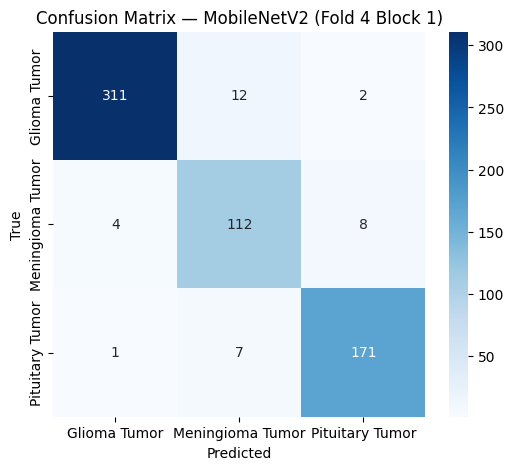

Fold: 5 block 5

Fold: 5 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4281 - accuracy: 0.5101 | val_loss: 0.3863 - val_accuracy: 0.6205
val_accuracy improved from 0.0000 to 0.6205, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


Epoch 2/50 | loss: 0.3086 - accuracy: 0.6886 | val_loss: 0.3227 - val_accuracy: 0.6532
val_accuracy improved from 0.6205 to 0.6532, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


Epoch 3/50 | loss: 0.2530 - accuracy: 0.7489 | val_loss: 0.2797 - val_accuracy: 0.7045
val_accuracy improved from 0.6532 to 0.7045, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


Epoch 4/50 | loss: 0.2245 - accuracy: 0.7724 | val_loss: 0.2606 - val_accuracy: 0.7356
val_accuracy improved from 0.7045 to 0.7356, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


...

Epoch 29/50 | loss: 0.1200 - accuracy: 0.8641 | val_loss: 0.1688 - val_accuracy: 0.8320
val_accuracy did not improve from 0.8336


Epoch 30/50 | loss: 0.1150 - accuracy: 0.8765 | val_loss: 0.1721 - val_accuracy: 0.8165
val_accuracy did not improve from 0.8336


Epoch 31/50 | loss: 0.1107 - accuracy: 0.8773 | val_loss: 0.1709 - val_accuracy: 0.8274
val_accuracy did not improve from 0.8336


Epoch 32/50 | loss: 0.1051 - accuracy: 0.8835 | val_loss: 0.1687 - val_accuracy: 0.8274
val_accuracy did not improve from 0.8336


Epoch 33/50 | loss: 0.1120 - accuracy: 0.8728 | val_loss: 0.1700 - val_accuracy: 0.8274
val_accuracy did not improve from 0.8336
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.165803  0.833593
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.84      0.88       287
Meningioma Tumor       0.67      0.72      0.69       166
 Pituitary Tumor       0.86      0.93      0.89       190

        accuracy                           0.83       643
       macro avg       0.82      0.83      0.82       643
    weighted avg       0.84      0.83      0.84       643



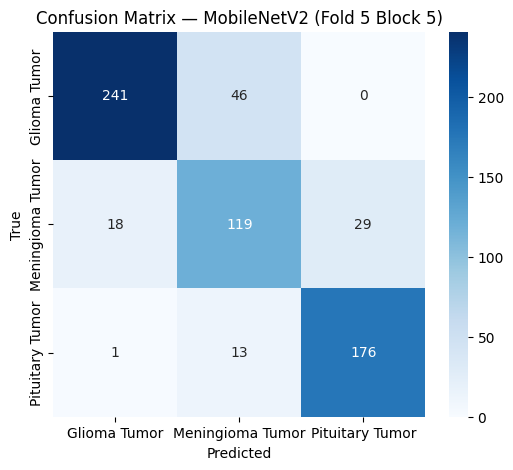

Fold: 5 block 4

Fold: 5 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1145 - accuracy: 0.8707 | val_loss: 0.1619 - val_accuracy: 0.8274
val_accuracy improved from 0.0000 to 0.8274, saving weights to /kaggle/working/MobileNetV2_block_4_fold_5.pth


Epoch 2/50 | loss: 0.0914 - accuracy: 0.8889 | val_loss: 0.1510 - val_accuracy: 0.8429
val_accuracy improved from 0.8274 to 0.8429, saving weights to /kaggle/working/MobileNetV2_block_4_fold_5.pth


Epoch 3/50 | loss: 0.0808 - accuracy: 0.9079 | val_loss: 0.1387 - val_accuracy: 0.8554
val_accuracy improved from 0.8429 to 0.8554, saving weights to /kaggle/working/MobileNetV2_block_4_fold_5.pth


Epoch 4/50 | loss: 0.0750 - accuracy: 0.9104 | val_loss: 0.1484 - val_accuracy: 0.8507
val_accuracy did not improve from 0.8554


...

Epoch 10/50 | loss: 0.0496 - accuracy: 0.9426 | val_loss: 0.1385 - val_accuracy: 0.8647
val_accuracy did not improve from 0.8678


Epoch 11/50 | loss: 0.0506 - accuracy: 0.9422 | val_loss: 0.1502 - val_accuracy: 0.8678
val_accuracy did not improve from 0.8678


Epoch 12/50 | loss: 0.0515 - accuracy: 0.9347 | val_loss: 0.1370 - val_accuracy: 0.8585
val_accuracy did not improve from 0.8678


Epoch 13/50 | loss: 0.0481 - accuracy: 0.9426 | val_loss: 0.1539 - val_accuracy: 0.8678
val_accuracy did not improve from 0.8678


Epoch 14/50 | loss: 0.0497 - accuracy: 0.9455 | val_loss: 0.1391 - val_accuracy: 0.8631
val_accuracy did not improve from 0.8678
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.146061  0.867807
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.86      0.90       287
Meningioma Tumor       0.73      0.77      0.75       166
 Pituitary Tumor       0.88      0.96      0.92       190

        accuracy                           0.87       643
       macro avg       0.85      0.86      0.86       643
    weighted avg       0.87      0.87      0.87       643



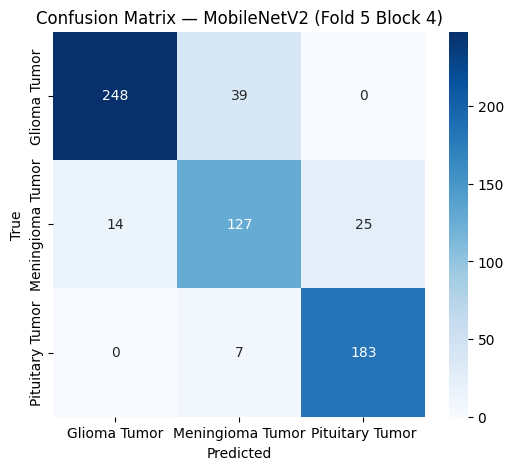

Fold: 5 block 3

Fold: 5 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0582 - accuracy: 0.9261 | val_loss: 0.1507 - val_accuracy: 0.8647
val_accuracy improved from 0.0000 to 0.8647, saving weights to /kaggle/working/MobileNetV2_block_3_fold_5.pth


Epoch 2/50 | loss: 0.0557 - accuracy: 0.9310 | val_loss: 0.1379 - val_accuracy: 0.8616
val_accuracy did not improve from 0.8647


Epoch 3/50 | loss: 0.0444 - accuracy: 0.9492 | val_loss: 0.1473 - val_accuracy: 0.8663
val_accuracy improved from 0.8647 to 0.8663, saving weights to /kaggle/working/MobileNetV2_block_3_fold_5.pth


Epoch 4/50 | loss: 0.0426 - accuracy: 0.9504 | val_loss: 0.1440 - val_accuracy: 0.8678
val_accuracy improved from 0.8663 to 0.8678, saving weights to /kaggle/working/MobileNetV2_block_3_fold_5.pth


...

Epoch 11/50 | loss: 0.0307 - accuracy: 0.9603 | val_loss: 0.1536 - val_accuracy: 0.8771
val_accuracy did not improve from 0.8787


Epoch 12/50 | loss: 0.0272 - accuracy: 0.9649 | val_loss: 0.1572 - val_accuracy: 0.8787
val_accuracy did not improve from 0.8787


Epoch 13/50 | loss: 0.0295 - accuracy: 0.9620 | val_loss: 0.1577 - val_accuracy: 0.8771
val_accuracy did not improve from 0.8787


Epoch 14/50 | loss: 0.0304 - accuracy: 0.9591 | val_loss: 0.1550 - val_accuracy: 0.8787
val_accuracy did not improve from 0.8787


Epoch 15/50 | loss: 0.0274 - accuracy: 0.9628 | val_loss: 0.1540 - val_accuracy: 0.8771
val_accuracy did not improve from 0.8787
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.147842  0.878694
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.90      0.92       287
Meningioma Tumor       0.78      0.75      0.76       166
 Pituitary Tumor       0.88      0.96      0.91       190

        accuracy                           0.88       643
       macro avg       0.86      0.87      0.87       643
    weighted avg       0.88      0.88      0.88       643



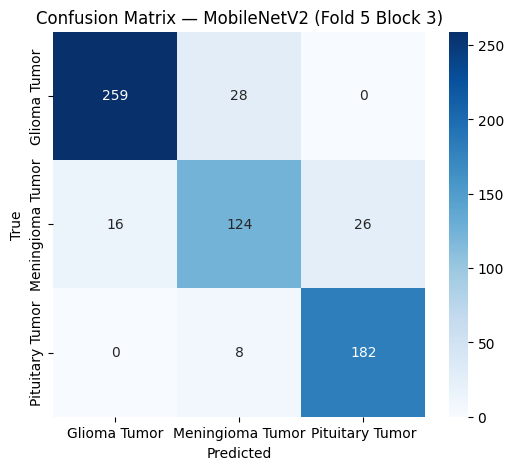

Fold: 5 block 2

Fold: 5 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,211,923
Non-trainable params: 15,792
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0400 - accuracy: 0.9475 | val_loss: 0.1756 - val_accuracy: 0.8694
val_accuracy improved from 0.0000 to 0.8694, saving weights to /kaggle/working/MobileNetV2_block_2_fold_5.pth


Epoch 2/50 | loss: 0.0349 - accuracy: 0.9521 | val_loss: 0.1489 - val_accuracy: 0.8694
val_accuracy did not improve from 0.8694


Epoch 3/50 | loss: 0.0347 - accuracy: 0.9583 | val_loss: 0.1708 - val_accuracy: 0.8802
val_accuracy improved from 0.8694 to 0.8802, saving weights to /kaggle/working/MobileNetV2_block_2_fold_5.pth


Epoch 4/50 | loss: 0.0296 - accuracy: 0.9641 | val_loss: 0.2189 - val_accuracy: 0.8725
val_accuracy did not improve from 0.8802


...

Epoch 10/50 | loss: 0.0190 - accuracy: 0.9727 | val_loss: 0.1830 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8865


Epoch 11/50 | loss: 0.0190 - accuracy: 0.9727 | val_loss: 0.1759 - val_accuracy: 0.8834
val_accuracy did not improve from 0.8865


Epoch 12/50 | loss: 0.0190 - accuracy: 0.9760 | val_loss: 0.1784 - val_accuracy: 0.8834
val_accuracy did not improve from 0.8865


Epoch 13/50 | loss: 0.0205 - accuracy: 0.9740 | val_loss: 0.1789 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8865


Epoch 14/50 | loss: 0.0196 - accuracy: 0.9748 | val_loss: 0.1791 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8865
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.161663   0.88647
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       287
Meningioma Tumor       0.82      0.72      0.77       166
 Pituitary Tumor       0.88      0.96      0.92       190

        accuracy                           0.89       643
       macro avg       0.87      0.87      0.87       643
    weighted avg       0.88      0.89      0.88       643



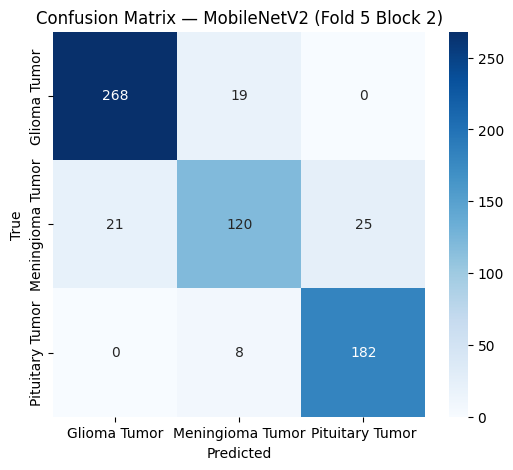

Fold: 5 block 1

Fold: 5 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0278 - accuracy: 0.9661 | val_loss: 0.1786 - val_accuracy: 0.8802
val_accuracy improved from 0.0000 to 0.8802, saving weights to /kaggle/working/MobileNetV2_block_1_fold_5.pth


Epoch 2/50 | loss: 0.0256 - accuracy: 0.9678 | val_loss: 0.1422 - val_accuracy: 0.8849
val_accuracy improved from 0.8802 to 0.8849, saving weights to /kaggle/working/MobileNetV2_block_1_fold_5.pth


Epoch 3/50 | loss: 0.0244 - accuracy: 0.9678 | val_loss: 0.1575 - val_accuracy: 0.8927
val_accuracy improved from 0.8849 to 0.8927, saving weights to /kaggle/working/MobileNetV2_block_1_fold_5.pth


Epoch 4/50 | loss: 0.0225 - accuracy: 0.9756 | val_loss: 0.1683 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8927


...

Epoch 7/50 | loss: 0.0141 - accuracy: 0.9818 | val_loss: 0.1670 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8958


Epoch 8/50 | loss: 0.0136 - accuracy: 0.9835 | val_loss: 0.1767 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8958


Epoch 9/50 | loss: 0.0151 - accuracy: 0.9810 | val_loss: 0.1679 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8958


Epoch 10/50 | loss: 0.0129 - accuracy: 0.9855 | val_loss: 0.1721 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8958


Epoch 11/50 | loss: 0.0124 - accuracy: 0.9855 | val_loss: 0.1727 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8958
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.155529  0.895801
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.93      0.94       287
Meningioma Tumor       0.82      0.77      0.79       166
 Pituitary Tumor       0.89      0.95      0.92       190

        accuracy                           0.90       643
       macro avg       0.88      0.88      0.88       643
    weighted avg       0.90      0.90      0.89       643



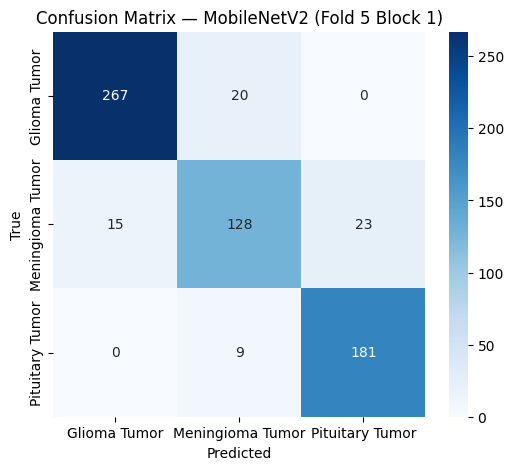

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5 = [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 5')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b5.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(4, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {5 - _} - block 5: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 5 - block 5: 85.74%
Accuracy unfreeze block 4 - block 5: 90.80%
Accuracy unfreeze block 3 - block 5: 91.49%
Accuracy unfreeze block 2 - block 5: 92.34%
Accuracy unfreeze block 1 - block 5: 92.92%
